# AP 155 Lab Exercise
---
## Exercise 4: Derivatives

_Instructions_: 
- **Report figure (See Problem 1):** Plot of mean absolute error vs. step size (spacing between points) when using the forward, backward, and central difference approach to get first derivative
- **Report discussion:** Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name_: Rivera, Kyle Florian 
- _Student No._: 2024-16197
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

![Figure 1: Mean Absolute Error of various derivative methods](mae_step.png)

Figure 1: Mean Absolute Error of various derivative methods. Note that forward and backward difference datapoints are overlapping.

### Report discussion

Looking at the log-log plot, the plots of forward and backward (non-central) difference show a slope of 1 while the plot of the central difference exhibit a slope of 2. Since the approximation for the differences are derived from the Taylor series expansion, an error arises from the truncation of higher order terms, which starts at the term $\pm\frac{h}{2}f''(x)$ for non-central differences, and term $\frac{h^2}{6}f'''(x)$ for central differences.

Given that we aim for $h<<1$, the terms including the one mentioned and beyond vanishes faster for central differences due to the $h^2$, unlike for non-central differences wherein it scales linearly. With this, we find that central differences yield a much accurate numerical derivative evaluation compare to non-central differences. Although it may be more accurate, there exists a tradeoff especially when we scale down the step size even more $<10^{-5}$, where we encounter subtractive cancellation, as evident on the graph.

Knowing this, we can infer the following:
* We use central differences as much as possible, and as long as the data allows it, i.e. if we have a rigid dataset or we are evaluating boundary value problems.
* We use forward differences if the starting point of a dataset do 
* We use backward difference when we are dealing with time-series data, i.e. live data points where the future point hasn't occured yet, and we want to evaluate the derivative at present time.


Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with ~150 words per question.

### Other comments
- Fun exercise. I got to try something different

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

Consider the function:
$$ f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$$

Say you start with 257 points from 0 to $4\pi$ 

We first find the analytical derivative $f'(x)$:
$$
\begin{align}
f'(x) &= 5x\cos\left(x + \frac{\pi}{4}\right) + 5\sin\left(x + \frac{\pi}{4}\right)
\end{align}
$$

In [2]:
def analytic_diff(x):
    analytic_diff = 5 * x * np.cos(1*x + np.pi/4) + 5 * np.sin(1*x+np.pi/4)
    return analytic_diff

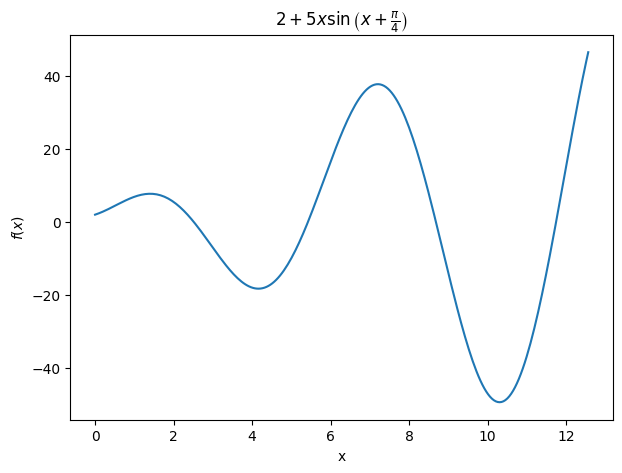

In [3]:
def f(x):
    return 2 + 5*x*np.sin(1*x+np.pi/4)
    
x = np.linspace(0, 4*np.pi, 257)
y = f(x)
    
fig, ax = plt.subplots(figsize = (7,5))
ax.plot(x, y)
ax.set_title(r"$2 + 5x\sin\left(x + \frac{\pi}{4}\right)$")
ax.set_ylabel("$f(x)$")
ax.set_xlabel("x")
plt.show()
fig.savefig('f_x.png')

- Create a function that gets the first derivative approximation using the forward, backward, and central difference formulas. (Bonus, not required): Make the function flexible to non-evenly spaced data

In [4]:
def forward_diff(x=x, f=f): # forward difference derivative
    h = np.roll(x, -1) - x 
    fi_plus = np.roll(f(x), -1)  
    f_diff = ((fi_plus - f(x)) / h)[:-1]
    return f_diff

def backward_diff(x=x, f=f): # backward difference derivative
    h = np.roll(x, 1) - x 
    fi = np.roll(f(x), 1)  
    f_diff = ((fi - f(x)) / h)[1:]
    return f_diff
    
def central_diff(x=x, f=f): # central difference
    h = np.roll(x, 1) - x 
    fi_plus = np.roll(f(x), 1)  
    fi_minus = np.roll(f(x), -1)  
    f_diff = ((fi_plus - fi_minus) / (2*h))[1:-1]
    return f_diff
# note: only this is not flexible to non-evenly spaced data. 2h assumes that x_i - x_{i-1} = x_{i+1} - x_i

For forward difference, the last datapoint is discarded by the nature of the algorithm.

For backward difference, the first datapoint is dropped.

For central difference, both the first and last datapoint is dropped.

- To give yourself a visualization, plot (in a single axis):
  - the three derivative approximations
  - the analytically derived function

The code we will write below might seem so complicated. I aimed to avoid repeatedly puting `ax.scatter` since I want to tidy it up a bit and put our graph settings in a different variable.

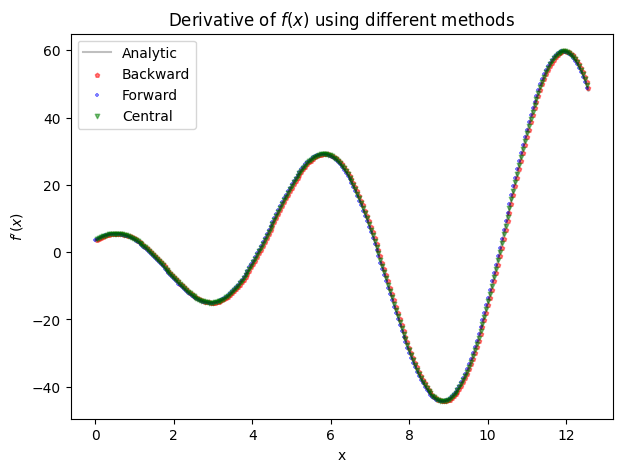

In [5]:
f_prime_back = backward_diff(x, f)
f_prime_forw = forward_diff(x, f)
f_prime_centre = central_diff(x, f)
f_prime_analytic = analytic_diff(x)

# set up plot settings
derivatives = [(backward_diff, "red", 0.5, "p", "Backward", slice(1, None)), 
               (forward_diff, "blue", 0.5, "+", "Forward", slice(0,-1)), 
               (central_diff, "green", 0.5, "v", "Central", slice(1,-1))]

size = 10
fig, ax = plt.subplots(figsize = (7,5))
ax.plot(x, f_prime_analytic, c="black", alpha=0.25, label="Analytic")
for method, color, alpha, marker, label, slic in derivatives: # iterate through the settings
    x_s = x
    ax.scatter(x_s[slic], method(x, f), c=color, alpha=alpha, s=size, marker=marker, label=label)
    
ax.legend()
ax.set_title(r"Derivative of $f(x)$ using different methods")
ax.set_ylabel("$f'(x)$")
ax.set_xlabel("x")
plt.show()

If we look very very closely (zoom in), we are missing a datapoint for backward and central difference at $x=0$ and missing a datapoint as well but for forward and central difference at $x=4\pi$.

- Get the mean absolute error of each of the approximations compared to the analytically derived function

In [6]:
"""
explanation ng code: 
because i want to save space (and practice being comfortable with this), we pack our 
settings into a list of tuples in the ff. format: (method, slicing technique)
we then iterate this when computing the mean average value
"""

diff = [(backward_diff, slice(1, None)), (forward_diff, slice(0,-1)), (central_diff, slice(1,-1))] 

def calculate_mae(x, f, diff):
    may_array = []
    for method, slic in diff:
        # print(f"{method}")
        y = analytic_diff(x)
        MAE = np.mean(np.abs(y[slic] - method(x, f)))
        # print(MAE)
        may_array.append(MAE)
    return may_array
        
maes = calculate_mae(x,f,diff)
mae_label = ["backward difference", "forward difference", "central difference"]

for label, mae_row in zip(mae_label, maes):
    print(f"{label}: {mae_row}") # lets print it

backward difference: 0.5005317898124997
forward difference: 0.4995543014855032
central difference: 0.009652197768684263


- Repeat the above step for increasing number of points (decreasing spacing) - instead of 256 points, take 512/1024/128/64 points, etc.

In [7]:
import pandas as pd # lets use pandas to put this in a table

resolution = np.array([64, 128, 256, 512, 1028])

mga_MAE = [] # putting our mae's here

for res in resolution:
    x = np.linspace(0, 4*np.pi, res)
    y = analytic_diff(x)
    maes = calculate_mae(x, f, diff)
    mga_MAE.append(maes)
    
df = pd.DataFrame(mga_MAE, index = resolution, columns = mae_label)
print(df)

      backward difference  forward difference  central difference
64               2.037293            2.021501            0.158411
128              1.009348            1.006001            0.039138
256              0.502508            0.501524            0.009728
512              0.250660            0.250415            0.002425
1028             0.124692            0.124629            0.000600


- (For the report) Make a plot of the mean absolute error vs the spacing between points. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation

In [8]:
resolution = np.logspace(1, 7, 50, dtype=int) # we generate an evenly spaced (in log-space) resolution list
step_size = 4*np.pi/resolution # reminder: 4*pi because that is our domain

mga_MAE = []

for res in resolution:
    x = np.linspace(0, 4*np.pi, res)
    y = analytic_diff(x)
    maes = calculate_mae(x, f, diff)
    mga_MAE.append(maes)

# we can uncomment this to show the datapoints
# df = pd.DataFrame(mga_MAE, index = resolution, columns = mae_label)
# print(df)

mga_MAE = np.transpose(mga_MAE) # we do this for easier plotting later

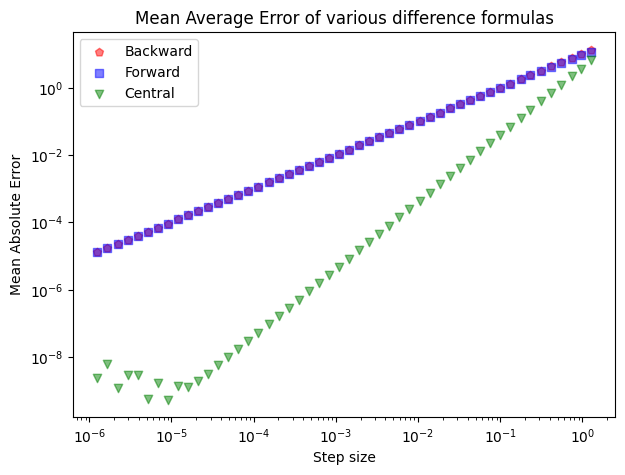

In [9]:
# print(step_size)
plot_settings = [("red", 0.5, "p", "Backward"), 
                 ("blue", 0.5, "s", "Forward"), 
                 ("green", 0.5, "v", "Central")]

fig, ax = plt.subplots(figsize = (7,5))
for mae, (color, alpha, marker, label) in zip(mga_MAE, plot_settings):
    ax.scatter(step_size, mae, c=color, alpha=alpha, marker=marker, label=label)
    # print(mae)
    
ax.legend()
ax.title
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel("Mean Absolute Error")
ax.set_xlabel("Step size")
ax.set_title("Mean Average Error of various difference formulas")
plt.savefig("mae_step.png")
plt.show()

#### Problem 1 code summary

The numerical derivative obtained via three different methods (forward, backward, and central difference) were compared to their analytic counterpart. In order to keep the operations vectorized, careful array slicing and rolling (or shifting) was utilized. Finally, we calculated the mean absolute error (MAE) in a similar fashion and plotted the relationship between MAE and the step size of our numerical derivative.

---

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [10]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, -1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[ 2.  3.  4.  5.  6.  7.  8.  9. 10.  1.]
[ 1.  1.  1.  1.  1.  1.  1.  1. -9.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
